In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


In [4]:
df = pd.read_pickle('../datos/intermedios/tablon_analitico_preparado.pkl')
df.head()

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,potencia_ac_kw,eficiencia,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,6259559.0
2020-05-15 00:00:00,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,6183645.0
2020-05-15 00:00:00,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,6987759.0
2020-05-15 00:00:00,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,7602960.0
2020-05-15 00:00:00,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,0.0,100.0,0.0,7158964.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-17 23:45:00,p2,q49J1IKaHRwDQnt,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,0.0,100.0,4157.0,520758.0
2020-06-17 23:45:00,p2,rrq4fwE8jgrTyWY,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,0.0,100.0,3931.0,121131356.0
2020-06-17 23:45:00,p2,vOuJvMaM2sgwLmb,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,0.0,100.0,4322.0,2427691.0


In [14]:
# Desde el punto de vista del proceso vamos a ver la IRRADIACIÓN DE LAS PLANTAS.
# Como hay sólo 1 sensor por planta, se puede utilizar 1 inversosr de cada planta y manejar menos datos. 
df.groupby('id_inversor')[['irradiacion_wh_m2','temperatura_ambiente_c','temperatura_modulo_c','potencia_dc_kw','potencia_ac_kw','eficiencia','energia_diaria_kwh','energia_total_kwh']].mean()

,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,potencia_ac_kw,eficiencia,energia_diaria_kwh,energia_total_kwh
id_inversor,,,,,,,,
1BY6WEcLGh8j5v7,0.230310,25.560769,31.182856,287.372098,281.124073,98.804774,3230.658151,6.377464e+06
1IF53ai7Xc0U56Y,0.232636,25.564750,31.259969,322.512552,315.369260,98.774348,3356.162374,6.313081e+06
3PZuoBAID5Wc2HD,0.232636,25.564306,31.259675,322.101567,314.967354,98.775095,3356.856357,7.117013e+06
4UPUqMRk7TRMgml,0.231055,28.102992,32.784212,277.760524,271.576886,98.856204,4143.422728,2.526560e+06
7JYdWkrLSPkdwr4,0.231856,25.564299,31.237183,313.289196,306.385671,98.779224,3325.810327,7.728914e+06
81aHJ1q11NBPMrL,0.232737,28.069400,32.772408,230.796317,225.728343,98.962018,2640.050635,1.126850e+09
9kRcWv60rDACzjR,0.232737,28.069400,32.772408,244.653027,239.281783,98.915883,2793.966510,2.215144e+09
Et9kgGMDl729KT4,0.231055,28.102992,32.784212,188.230376,184.230269,98.999683,2356.332188,1.773121e+06
IQ2d7wF4YD8zU1Q,0.210772,27.407110,31.561333,285.525112,279.190055,98.793685,4116.486644,1.991098e+07


In [12]:
captacion = df.loc[(df['id_inversor'] == '1BY6WEcLGh8j5v7') | (df['id_inversor'] == 'xMbIugepa2P7lBB'), 'id_planta':'temperatura_modulo_c']
captacion

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c
fecha_hora,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507
2020-05-15 00:15:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:15:00,0,15,0.0,25.084589,22.761668
2020-05-15 00:30:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:30:00,0,30,0.0,24.935753,22.592306
2020-05-15 00:45:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:45:00,0,45,0.0,24.846130,22.360852
2020-05-15 01:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,01:00:00,1,0,0.0,24.621525,22.165423
...,...,...,...,...,...,...,...,...,...,...,...
2020-06-17 22:45:00,p2,xMbIugepa2P7lBB,sensor_p2,6,17,22:45:00,22,45,0.0,23.511703,22.856201
2020-06-17 23:00:00,p2,xMbIugepa2P7lBB,sensor_p2,6,17,23:00:00,23,0,0.0,23.482282,22.744190
2020-06-17 23:15:00,p2,xMbIugepa2P7lBB,sensor_p2,6,17,23:15:00,23,15,0.0,23.354743,22.492245


In [17]:
resultado_captacion = captacion.groupby('id_planta').agg({

'irradiacion_wh_m2': lambda x: x[x!=0].mean(),
'temperatura_ambiente_c': 'mean',
'temperatura_modulo_c': 'mean'
}).round(2)

resultado_captacion

,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c
id_planta,,,
p1,0.41,25.56,31.18
p2,0.37,27.41,31.56


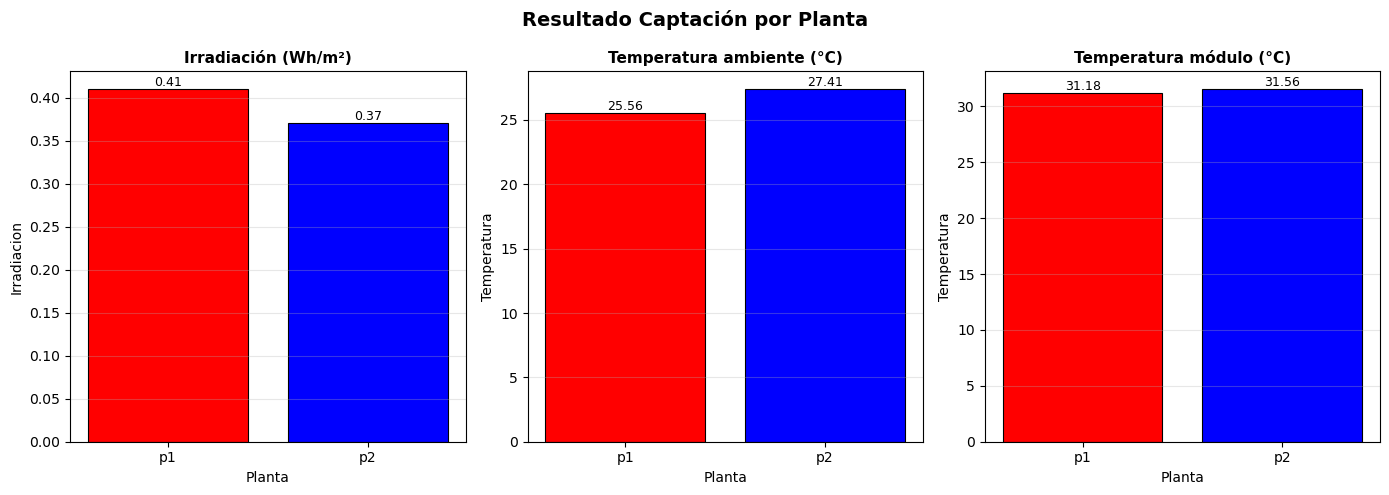

In [21]:
# Gráfico de barras con subplots - resultado_captacion (Planta 1 azul, Planta 2 rojo)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Resultado Captación por Planta', fontsize=14, fontweight='bold')

variables = ['irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c']
titulos = ['Irradiación (Wh/m²)', 'Temperatura ambiente (°C)', 'Temperatura módulo (°C)']

# Colores: p1 (planta1) = azul, p2 (planta2) = rojo
colores = ['red', 'blue']  # Orden: p1, p2 en resultado_captacion.index

for i, (var, titulo) in enumerate(zip(variables, titulos)):
    plantas = resultado_captacion.index
    valores = resultado_captacion[var].values
    bars = axes[i].bar(plantas, valores, color=colores, edgecolor='black', linewidth=0.8)
    axes[i].set_title(titulo, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Planta')
    axes[i].set_ylabel(var.split('_')[0].title())
    for j, bar in enumerate(bars):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                     f'{valores[j]:.2f}', ha='center', va='bottom', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

INSIGHT 4:
Parece que las dos plantas tienen niveles de irradiación normales y esperables. Aunque la temperatura de planta 2 tenga temperatura mayor (ligeramente) que planta 1, es normal que tenga menor irradiación. Eso depende de la humedad, la altitud, la exposición al sol, y muchos otros factores. La irradiación parece correcta en ambas plantas. Habrá que buscar el problema en otra fase posterior del proceso. Como es lógico, la temperatura del módulo está más correlacionada con la irradiación que la temperatura ambiente.

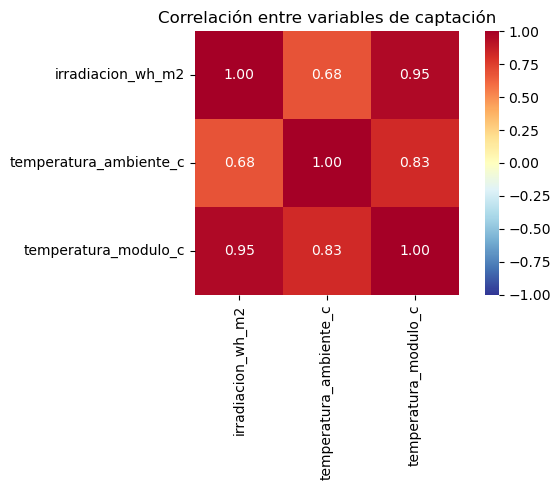

In [23]:
# correlación entre la captación y las tres variables: 'irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c'
vars_captacion = ['irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c']
corr_captacion = captacion[vars_captacion].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_captacion, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación entre variables de captación')
plt.tight_layout()
plt.show()


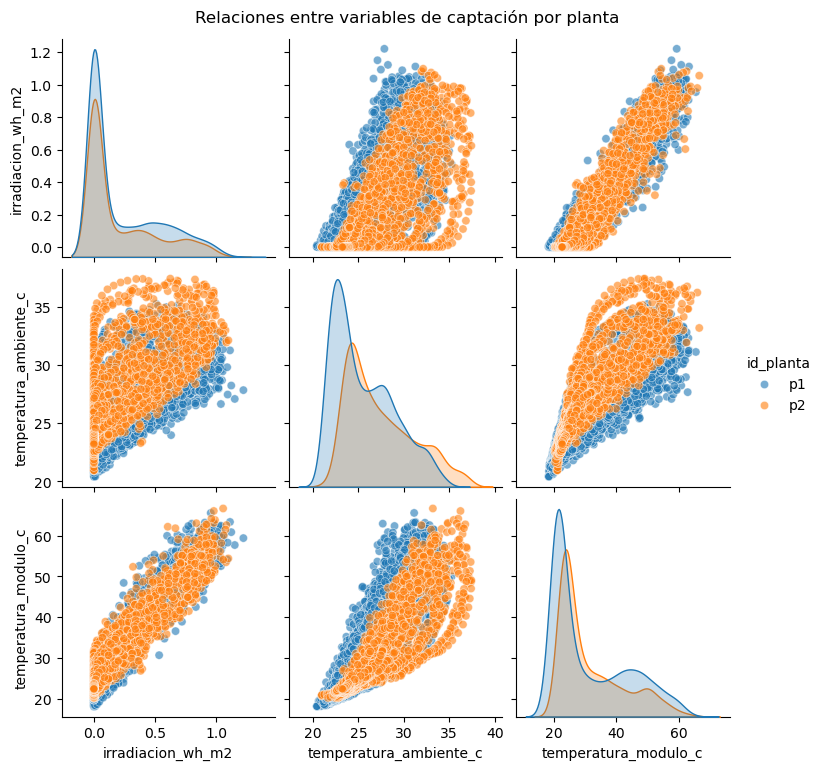

In [25]:
# Pair plot de variables de captación por planta (añadido alpha a los gráficos)
vars_captacion = ['irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c']
sns.pairplot(captacion[vars_captacion + ['id_planta']], hue='id_planta', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre variables de captación por planta', y=1.02)
plt.show()

In [35]:
irradiacion_hora_planta= pd.pivot_table(captacion, index='hora', columns='id_planta', values='irradiacion_wh_m2', aggfunc='sum')
irradiacion_hora_planta

id_planta,p1,p2
hora,,
0,0.000000,0.000102
1,0.000000,0.000106
2,0.000000,0.000115
3,0.000000,0.000344
4,0.000000,0.000526
5,0.014891,0.023962
6,5.244716,3.709666
7,25.753335,16.302686
8,50.683759,33.394774


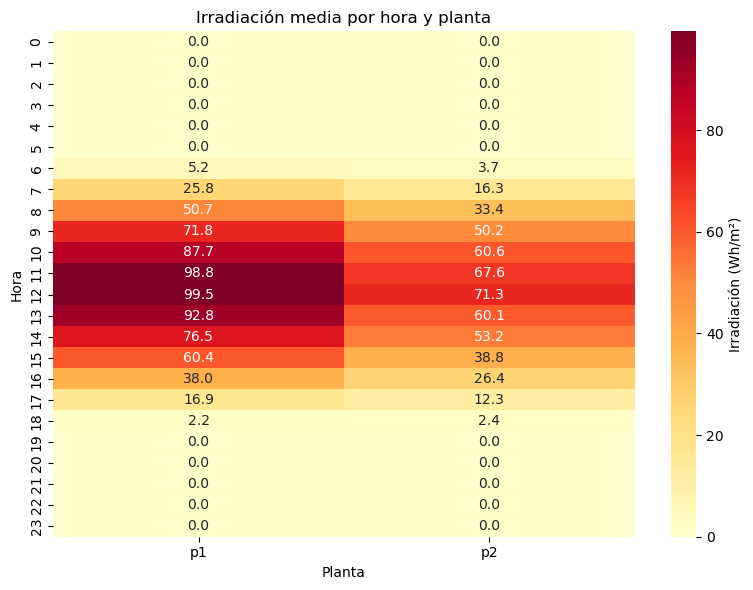

In [36]:
# Heatmap de irradiación por hora y planta
plt.figure(figsize=(8, 6))
sns.heatmap(irradiacion_hora_planta, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Irradiación (Wh/m²)'})
plt.title('Irradiación media por hora y planta')
plt.xlabel('Planta')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

In [37]:
temp_ambiente_hora_planta= pd.pivot_table(captacion, index='hora', columns='id_planta', values='temperatura_ambiente_c', aggfunc='mean')
temp_ambiente_hora_planta

id_planta,p1,p2
hora,,
0,22.803975,24.802297
1,22.627098,24.544407
2,22.460108,24.169886
3,22.319239,23.969480
4,22.171525,23.820606
5,22.061139,23.695390
6,22.201285,24.027258
7,23.344961,25.192366
8,24.917594,26.638100


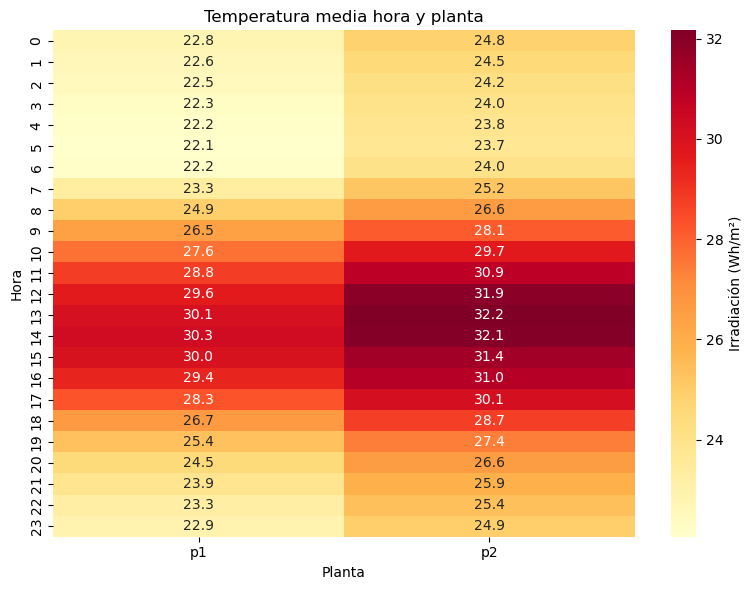

In [39]:
# Heatmap de temperatura ambiente por hora y planta
plt.figure(figsize=(8, 6))
sns.heatmap(temp_ambiente_hora_planta, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Irradiación (Wh/m²)'})
plt.title('Temperatura media hora y planta')
plt.xlabel('Planta')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()